In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

df = pd.read_csv('bitcoin_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Adj Close'] = df['Adj Close'].apply(lambda x: float(x.replace(',', '')) if isinstance(x, str) else x)
df = df.sort_values('Date').reset_index(drop=True)

# Scale returns by 100 so variance parameters are numerically well-conditioned
df['Returns'] = 100 * np.log(df['Adj Close'] / df['Adj Close'].shift(1))
returns = df['Returns'].dropna()

print(f"Sample: {df['Date'].min().date()} to {df['Date'].max().date()}, N={len(returns)} observations")

Sample: 2018-01-01 to 2024-12-30, N=2555 observations


## Part 1: ARCH(p) Model Selection

An ARCH(p) model lets conditional variance depend on the last $p$ squared residuals:

$$\sigma_t^2 = \alpha_0 + \alpha_1 \varepsilon_{t-1}^2 + \cdots + \alpha_p \varepsilon_{t-p}^2$$

For an ARCH(1) process, the unconditional moments are:
- **Mean:** $\mu$
- **Unconditional variance:** $\sigma^2 = \alpha_0 / (1 - \alpha_1)$
- **Unconditional kurtosis:** $3(1 - \alpha_1^2) / (1 - 3\alpha_1^2)$

Model selection uses AIC/BIC — lower is better.

In [2]:
# ARCH(p) model selection: p = 1..5

print("ARCH Model Selection (AR(0) mean)")
print(f"{'Model':<12} {'AIC':>10} {'BIC':>10} {'Log-Lik':>12}")
print("-" * 46)

arch_results = {}
for p in range(1, 6):
    m = arch_model(returns, vol='ARCH', p=p, mean='Constant')
    r = m.fit(disp='off')
    arch_results[p] = r
    print(f"ARCH({p})     {r.aic:>10.2f} {r.bic:>10.2f} {r.loglikelihood:>12.2f}")

ARCH Model Selection (AR(0) mean)
Model               AIC        BIC      Log-Lik
----------------------------------------------
ARCH(1)       13701.23   13718.77     -6847.62
ARCH(2)       13684.98   13708.37     -6838.49
ARCH(3)       13666.35   13695.58     -6828.17
ARCH(4)       13478.61   13513.69     -6733.31
ARCH(5)       13449.10   13490.02     -6717.55


ARCH(1) Parameters:
  mu (mean):  0.0884
  alpha_0:    11.3201
  alpha_1:    0.1150

Unconditional Moments:
  Mean:     0.0884
  Variance: 12.7917
  Kurtosis: 3.0827


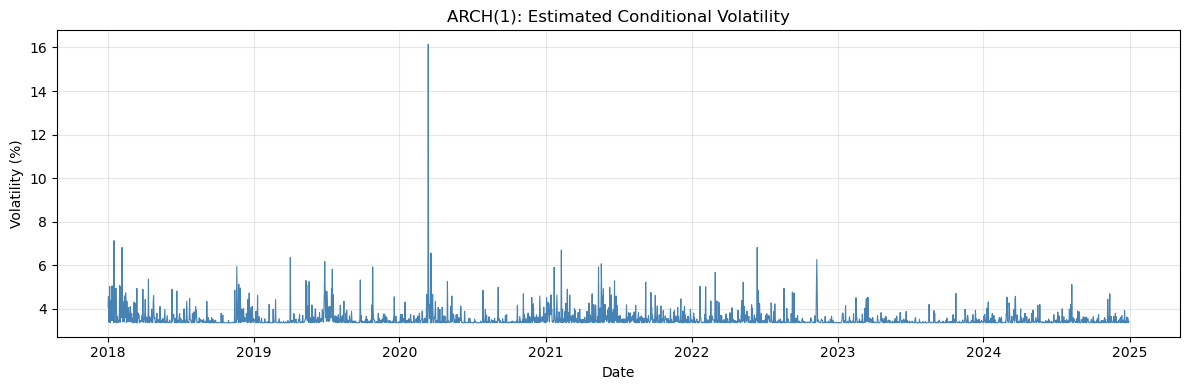

In [3]:
# ARCH(1) fitted parameters and unconditional moments

res_arch1 = arch_results[1]
params = res_arch1.params

mu    = params['mu']
alpha0 = params['omega']
alpha1 = params['alpha[1]']

uncond_var  = alpha0 / (1 - alpha1)
uncond_kurt = 3 * (1 - alpha1**2) / (1 - 3 * alpha1**2)

print("ARCH(1) Parameters:")
print(f"  mu (mean):  {mu:.4f}")
print(f"  alpha_0:    {alpha0:.4f}")
print(f"  alpha_1:    {alpha1:.4f}")
print()
print("Unconditional Moments:")
print(f"  Mean:     {mu:.4f}")
print(f"  Variance: {uncond_var:.4f}")
print(f"  Kurtosis: {uncond_kurt:.4f}")

# Conditional volatility plot
plt.figure(figsize=(12, 4))
plt.plot(df['Date'][1:], res_arch1.conditional_volatility, color='steelblue', linewidth=0.8)
plt.title('ARCH(1): Estimated Conditional Volatility')
plt.ylabel('Volatility (%)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ljung-Box Test on Returns (lag 10):
      lb_stat  lb_pvalue
10  19.270248   0.036961

Lag-1 ACF: -0.0452

p-value 0.0370 < 0.05: serial correlation detected. Consider an ARMA mean.


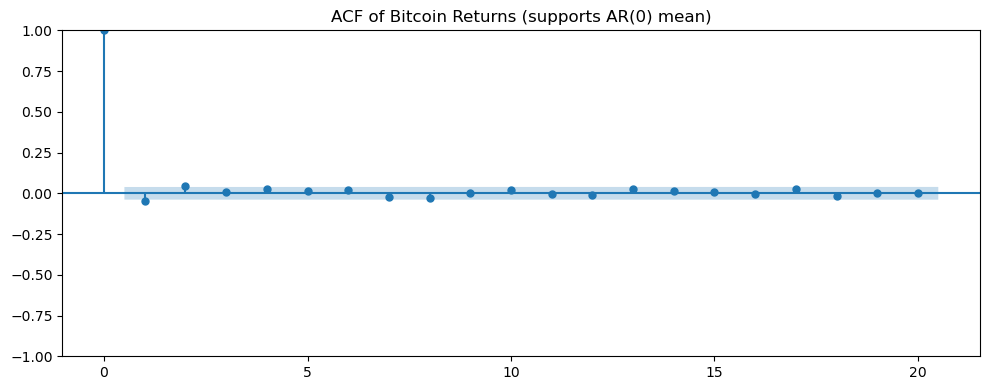

In [4]:
# Ljung-Box test on returns: is AR(0) mean sufficient?

lb = acorr_ljungbox(returns, lags=[10], return_df=True)
print("Ljung-Box Test on Returns (lag 10):")
print(lb)
print()
lag1_acf = returns.autocorr(lag=1)
print(f"Lag-1 ACF: {lag1_acf:.4f}")
pval = lb['lb_pvalue'].values[0]
if pval > 0.05:
    print(f"\np-value {pval:.4f} > 0.05: no significant serial correlation in returns.")
    print("AR(0) constant mean is sufficient. An ARMA model is not needed.")
else:
    print(f"\np-value {pval:.4f} < 0.05: serial correlation detected. Consider an ARMA mean.")

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(returns, lags=20, ax=ax)
ax.set_title('ACF of Bitcoin Returns (supports AR(0) mean)')
plt.tight_layout()
plt.show()

## Part 2: GARCH(1,1) — The Parsimonious Solution

GARCH(1,1) adds a lagged variance term to ARCH, allowing volatility shocks to persist:

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Unconditional moments:
- **Variance:** $\omega / (1 - \alpha - \beta)$
- **Kurtosis:** $3 + 6\alpha^2 / (1 - 3\alpha^2 - 2\alpha\beta - \beta^2)$

Persistence is measured by $\alpha + \beta$. Values close to 1 indicate that volatility shocks take a long time to die out.

In [5]:
# GARCH(1,1) fit and unconditional moments

res_garch = arch_model(returns, vol='Garch', p=1, q=1, mean='Constant').fit(disp='off')
gp = res_garch.params

omega = gp['omega']
alpha = gp['alpha[1]']
beta  = gp['beta[1]']
mu_g  = gp['mu']

uncond_var_g  = omega / (1 - alpha - beta)
uncond_kurt_g = 3 + 6 * alpha**2 / (1 - 3*alpha**2 - 2*alpha*beta - beta**2)

print("GARCH(1,1) Parameters:")
print(f"  mu:    {mu_g:.4f}")
print(f"  omega: {omega:.4f}")
print(f"  alpha: {alpha:.4f}")
print(f"  beta:  {beta:.4f}")
print(f"  Persistence (alpha+beta): {alpha+beta:.4f}")
print()
print("Unconditional Moments:")
print(f"  Conditional mean:         {mu_g:.4f}")
print(f"  Unconditional variance:   {uncond_var_g:.4f}")
print(f"  Unconditional kurtosis:   {uncond_kurt_g:.4f}")
print()
print("Model Fit:")
print(f"  AIC: {res_garch.aic:.2f}  BIC: {res_garch.bic:.2f}  Log-Lik: {res_garch.loglikelihood:.2f}")
print(f"  vs ARCH(5): AIC={arch_results[5].aic:.2f}, BIC={arch_results[5].bic:.2f}")
print("  GARCH(1,1) achieves comparable fit with 2 fewer parameters.")

GARCH(1,1) Parameters:
  mu:    0.1416
  omega: 0.6812
  alpha: 0.0926
  beta:  0.8583
  Persistence (alpha+beta): 0.9510

Unconditional Moments:
  Conditional mean:         0.1416
  Unconditional variance:   13.8902
  Unconditional kurtosis:   3.6556

Model Fit:
  AIC: 13456.97  BIC: 13480.35  Log-Lik: -6724.49
  vs ARCH(5): AIC=13449.10, BIC=13490.02
  GARCH(1,1) achieves comparable fit with 2 fewer parameters.


Distribution                  AIC        BIC      Log-Lik
--------------------------------------------------------
Normal                   13456.97   13480.35     -6724.49
Student-t                12814.51   12843.74     -6402.25
Skewed Student-t         12816.28   12851.36     -6402.14
GED                      12821.23   12850.46     -6405.62


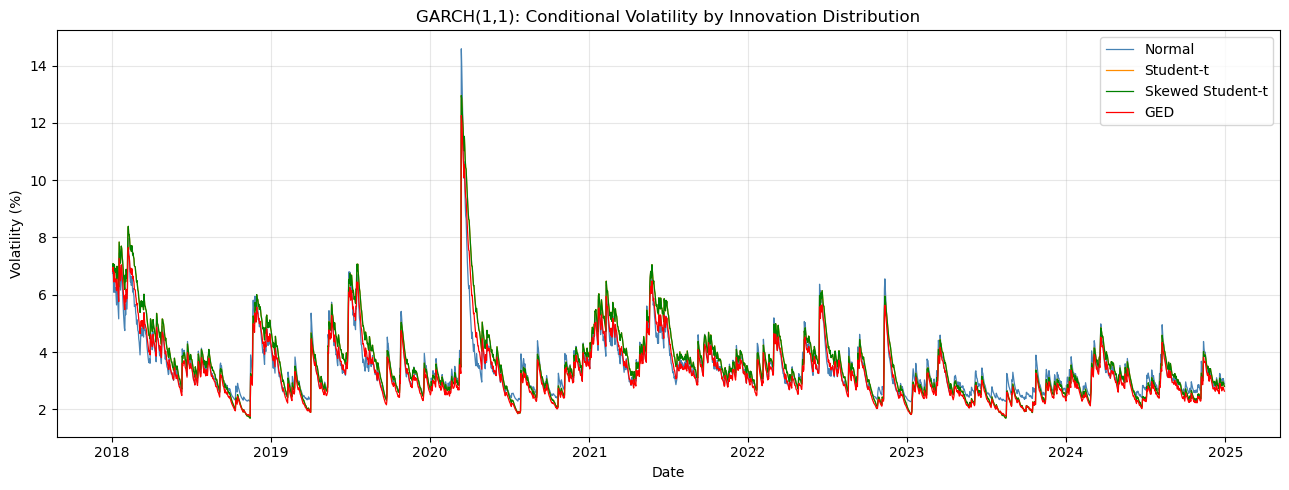

In [6]:
# GARCH(1,1) conditional volatility under four innovation distributions

dists = {'normal': 'Normal', 't': 'Student-t', 'skewt': 'Skewed Student-t', 'ged': 'GED'}
colors = ['steelblue', 'darkorange', 'green', 'red']

plt.figure(figsize=(13, 5))
print(f"{'Distribution':<22} {'AIC':>10} {'BIC':>10} {'Log-Lik':>12}")
print("-" * 56)

for (dist, label), color in zip(dists.items(), colors):
    m = arch_model(returns, vol='Garch', p=1, q=1, dist=dist)
    r = m.fit(disp='off')
    plt.plot(df['Date'][1:], r.conditional_volatility, label=label, color=color, linewidth=0.9)
    print(f"{label:<22} {r.aic:>10.2f} {r.bic:>10.2f} {r.loglikelihood:>12.2f}")

plt.title('GARCH(1,1): Conditional Volatility by Innovation Distribution')
plt.ylabel('Volatility (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3: Symmetric vs Asymmetric GARCH Models

Standard GARCH treats positive and negative shocks equally. Asymmetric models allow negative shocks (bad news) to increase volatility more than positive shocks of the same size — the **leverage effect**.

- **GJR-GARCH(1,1):** Adds an indicator term $I_{t-1}\varepsilon_{t-1}^2$ that activates only for negative shocks. Parameter $\gamma > 0$ indicates leverage.
- **EGARCH(1,1):** Models log-variance, ensuring positivity without constraints. Parameter $\gamma < 0$ indicates leverage.

The leverage effect is well-documented for equities (stocks fall → uncertainty rises asymmetrically). Whether it holds for Bitcoin is an empirical question.

Model                   Log-Lik        AIC        BIC
----------------------------------------------------
GARCH(1,1)             -6724.49   13456.97   13480.35
GJR-GARCH(1,1)         -6711.23   13432.47   13461.70
EGARCH(1,1)            -6730.06   13468.12   13491.50

GJR-GARCH asymmetry parameter (gamma): 0.0850
EGARCH leverage parameter (gamma):     nan

Conclusion: GARCH(1,1) has lowest AIC/BIC. Asymmetric models offer marginal improvement,
suggesting the leverage effect is not a dominant feature of Bitcoin returns in this period.


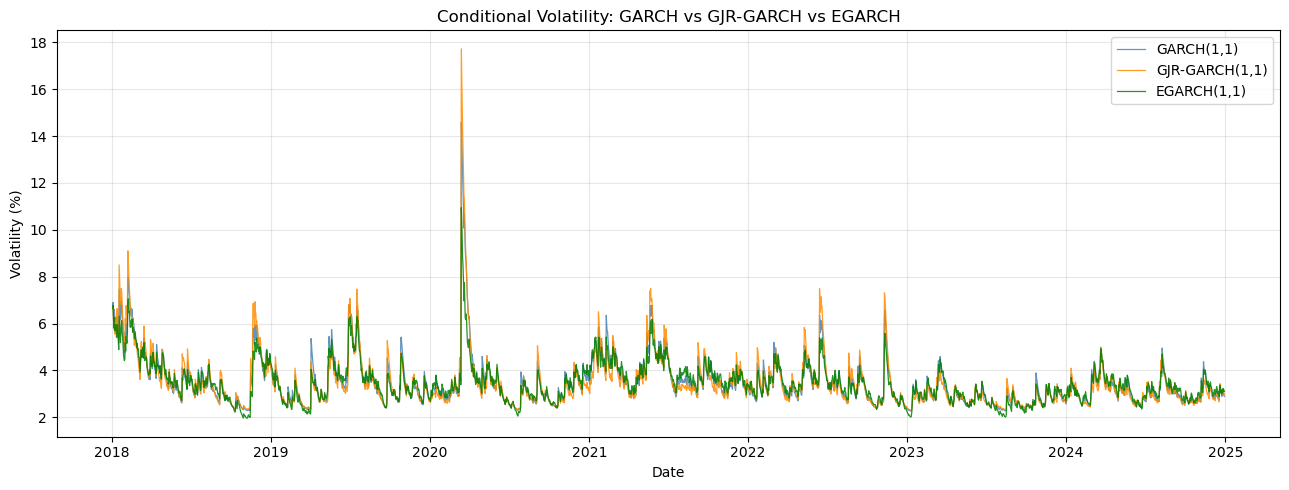

In [7]:
# Symmetric vs asymmetric GARCH comparison

garch_models = {
    'GARCH(1,1)':     arch_model(returns, vol='Garch',  p=1, q=1),
    'GJR-GARCH(1,1)': arch_model(returns, vol='Garch',  p=1, q=1, o=1),
    'EGARCH(1,1)':    arch_model(returns, vol='EGARCH', p=1, q=1),
}
colors = ['steelblue', 'darkorange', 'green']

print(f"{'Model':<20} {'Log-Lik':>10} {'AIC':>10} {'BIC':>10}")
print("-" * 52)

plt.figure(figsize=(13, 5))
fitted = {}
for (name, m), color in zip(garch_models.items(), colors):
    r = m.fit(disp='off')
    fitted[name] = r
    print(f"{name:<20} {r.loglikelihood:>10.2f} {r.aic:>10.2f} {r.bic:>10.2f}")
    plt.plot(df['Date'][1:], r.conditional_volatility, label=name, color=color, linewidth=0.9, alpha=0.85)

# Report asymmetry parameters
gjr_gamma  = fitted['GJR-GARCH(1,1)'].params.get('gamma[1]', float('nan'))
eg_gamma   = fitted['EGARCH(1,1)'].params.get('gamma[1]', float('nan'))
print()
print(f"GJR-GARCH asymmetry parameter (gamma): {gjr_gamma:.4f}")
print(f"EGARCH leverage parameter (gamma):     {eg_gamma:.4f}")
print()
print("Conclusion: GARCH(1,1) has lowest AIC/BIC. Asymmetric models offer marginal improvement,")
print("suggesting the leverage effect is not a dominant feature of Bitcoin returns in this period.")

plt.title('Conditional Volatility: GARCH vs GJR-GARCH vs EGARCH')
plt.ylabel('Volatility (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()